# German Credit Dataset — XGBoost Modeling, Optimization & Fairness Audit

This notebook provides an end-to-end evaluation of **XGBoost (eXtreme Gradient Boosting)** on the UCI Statlog German Credit Dataset (1,000 applicants × 21 attributes).

### Notebook Objectives:
1. **Data Loading & Categorical Decoding**: Load raw `german.data` and convert A-codes into human-readable business terms.
2. **Feature Engineering**: Extract protected attributes (`sex`, `age_group`, `foreign_worker`).
3. **Data Preprocessing**: Preprocess legitimate risk features using `ColumnTransformer` (`StandardScaler` + `OneHotEncoder`).
4. **XGBoost Baseline & Hyperparameter Optimization**: Train baseline XGBoost, perform grid search tuning for optimal parameters (`max_depth`, `learning_rate`, `n_estimators`, `scale_pos_weight`), and evaluate performance.
5. **Explainability (SHAP)**: Compute global TreeSHAP feature attributions.
6. **Subgroup Fairness Audit**: Evaluate Disparate Impact Ratio (DIR), Statistical Parity Difference (SPD), and Equal Opportunity Difference (EOD) across protected demographic subgroups.


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, roc_curve
)

import xgboost as xgb
import shap

print(f"XGBoost Version: {xgb.__version__}")
print(f"SHAP Version: {shap.__version__}")


XGBoost Version: 3.0.5
SHAP Version: 0.52.0


In [2]:
# Define column names matching german.doc
columns = [
    'checking_account_status', 'duration_months', 'credit_history',
    'purpose', 'credit_amount', 'savings_account', 'employment_since',
    'installment_rate_pct', 'personal_status_sex', 'other_debtors',
    'residence_since', 'property', 'age', 'other_installment_plans',
    'housing', 'existing_credits_count', 'job', 'num_dependents',
    'telephone', 'foreign_worker', 'target'
]

decode_maps = {
    'checking_account_status': {'A11': '< 0 DM', 'A12': '0-200 DM', 'A13': '>= 200 DM', 'A14': 'no checking account'},
    'credit_history': {'A30': 'no credits/all paid', 'A31': 'all paid (this bank)', 'A32': 'existing paid duly', 'A33': 'delay in past', 'A34': 'critical/other credits'},
    'purpose': {'A40': 'car (new)', 'A41': 'car (used)', 'A42': 'furniture/equipment', 'A43': 'radio/tv', 'A44': 'domestic appliances', 'A45': 'repairs', 'A46': 'education', 'A47': 'vacation', 'A48': 'retraining', 'A49': 'business', 'A410': 'other'},
    'savings_account': {'A61': '< 100 DM', 'A62': '100-500 DM', 'A63': '500-1000 DM', 'A64': '>= 1000 DM', 'A65': 'unknown/none'},
    'employment_since': {'A71': 'unemployed', 'A72': '< 1 yr', 'A73': '1-4 yrs', 'A74': '4-7 yrs', 'A75': '>= 7 yrs'},
    'personal_status_sex': {'A91': 'male:divorced/separated', 'A92': 'female:div/sep/married', 'A93': 'male:single', 'A94': 'male:married/widowed', 'A95': 'female:single'},
    'other_debtors': {'A101': 'none', 'A102': 'co-applicant', 'A103': 'guarantor'},
    'property': {'A121': 'real estate', 'A122': 'savings/insurance', 'A123': 'car/other', 'A124': 'unknown/none'},
    'other_installment_plans': {'A141': 'bank', 'A142': 'stores', 'A143': 'none'},
    'housing': {'A151': 'rent', 'A152': 'own', 'A153': 'for free'},
    'job': {'A171': 'unemployed/unskilled non-res', 'A172': 'unskilled resident', 'A173': 'skilled', 'A174': 'management/self-employed/highly qualified'},
    'telephone': {'A191': 'none', 'A192': 'yes'},
    'foreign_worker': {'A201': 'yes', 'A202': 'no'}
}

# Locate dataset path
data_path = 'data/german.data' if os.path.exists('data/german.data') else '../data/german.data'
if not os.path.exists(data_path):
    data_path = 'c:/Users/mahes/Desktop/Lloyds/Version-German-Credit-Data/data/german.data'

df_raw = pd.read_csv(data_path, sep=r'\s+', header=None, names=columns)

# Decode categorical columns
df = df_raw.copy()
for col, mapping in decode_maps.items():
    df[col] = df[col].map(mapping).fillna(df[col])

# Remap target: 1 = Good credit (Approved -> 1), 2 = Bad credit (Rejected -> 0)
df['target'] = df['target'].map({1: 1, 2: 0})

print(f"Dataset Shape: {df.shape}")
print(f"Target Distribution:\n{df['target'].value_counts(normalize=True)}")
df.head(3)


Dataset Shape: (1000, 21)
Target Distribution:
target
1    0.7
0    0.3
Name: proportion, dtype: float64


,checking_account_status,duration_months,credit_history,purpose,credit_amount,savings_account,employment_since,installment_rate_pct,personal_status_sex,other_debtors,...,property,age,other_installment_plans,housing,existing_credits_count,job,num_dependents,telephone,foreign_worker,target
0,< 0 DM,6,critical/other credits,radio/tv,1169,unknown/none,>= 7 yrs,4,male:single,none,...,real estate,67,none,own,2,skilled,1,yes,yes,1
1,0-200 DM,48,existing paid duly,radio/tv,5951,< 100 DM,1-4 yrs,2,female:div/sep/married,none,...,real estate,22,none,own,1,skilled,1,none,yes,0
2,no checking account,12,critical/other credits,education,2096,< 100 DM,4-7 yrs,2,male:single,none,...,real estate,49,none,own,1,unskilled resident,2,none,yes,1


In [3]:
# Extract protected & sensitive attributes
df['sex'] = df['personal_status_sex'].apply(lambda x: 'female' if 'female' in str(x).lower() else 'male')
df['age_group'] = df['age'].apply(lambda x: 'young (<25)' if x < 25 else '25+')

print("Protected Attribute Favorable Rates (Base Rates):")
for attr in ['sex', 'age_group', 'foreign_worker']:
    rates = df.groupby(attr)['target'].agg(['count', 'mean'])
    rates['mean'] = (rates['mean'] * 100).round(2).astype(str) + '%'
    print(f"\n--- {attr} ---")
    print(rates)


Protected Attribute Favorable Rates (Base Rates):

--- sex ---
        count    mean
sex                  
female    310  64.84%
male      690  72.32%

--- age_group ---
             count    mean
age_group                 
25+            851  71.92%
young (<25)    149  59.06%

--- foreign_worker ---
                count    mean
foreign_worker               
no                 37  89.19%
yes               963  69.26%


In [4]:
# Legitimate financial risk features (excluding target and protected demographic attributes)
numerical_cols = [
    'duration_months', 'credit_amount', 'installment_rate_pct',
    'residence_since', 'age', 'existing_credits_count', 'num_dependents'
]

categorical_cols = [
    'checking_account_status', 'credit_history', 'purpose',
    'savings_account', 'employment_since', 'other_debtors',
    'property', 'other_installment_plans', 'housing', 'job', 'telephone'
]

feature_cols = numerical_cols + categorical_cols
X = df[feature_cols].copy()
y = df['target'].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape[0]} rows")
print(f"Testing set:  {X_test.shape[0]} rows")

# Build ColumnTransformer Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols)
    ]
)

# Fit preprocessor on training data
X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc = preprocessor.transform(X_test)

# Get feature names after one-hot encoding
cat_encoder = preprocessor.named_transformers_['cat']
encoded_cat_cols = cat_encoder.get_feature_names_out(categorical_cols).tolist()
all_feature_names = numerical_cols + encoded_cat_cols

print(f"Total processed features: {len(all_feature_names)}")


Training set: 700 rows
Testing set:  300 rows
Total processed features: 55


In [5]:
# Initialize Baseline XGBoost Classifier
xgb_baseline = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    eval_metric='logloss',
    random_state=42
)

xgb_baseline.fit(X_train_proc, y_train)

y_pred_base = xgb_baseline.predict(X_test_proc)
y_prob_base = xgb_baseline.predict_proba(X_test_proc)[:, 1]

print("=== Baseline XGBoost Metrics ===")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_base):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_base):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_base):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_base):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_prob_base):.4f}")


=== Baseline XGBoost Metrics ===
Accuracy:  0.7267
Precision: 0.7735
Recall:    0.8619
F1-Score:  0.8153
ROC-AUC:   0.7394


In [6]:
# Define hyperparameter grid for XGBoost optimization
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 4, 5, 6],
    'learning_rate': [0.03, 0.05, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
    'scale_pos_weight': [1.0, 2.33]  # Account for 70:30 class imbalance
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=xgb.XGBClassifier(eval_metric='logloss', random_state=42),
    param_grid=param_grid,
    scoring='roc_auc',
    cv=cv,
    n_jobs=-1,
    verbose=1
)

print("Starting Grid Search Tuning for XGBoost...")
grid_search.fit(X_train_proc, y_train)

print(f"\nBest Parameters: {grid_search.best_params_}")
print(f"Best CV ROC-AUC: {grid_search.best_score_:.4f}")

# Best tuned XGBoost model
best_xgb = grid_search.best_estimator_


Starting Grid Search Tuning for XGBoost...
Fitting 5 folds for each of 432 candidates, totalling 2160 fits

Best Parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.03, 'max_depth': 3, 'n_estimators': 300, 'scale_pos_weight': 2.33, 'subsample': 0.8}
Best CV ROC-AUC: 0.7933


Evaluating the Gird Search configurations for fairness

In [22]:
# ============================================================
# GRID SEARCH: ACCURACY vs PROTECTED-GROUP ACCURACY DISPARITY
# ============================================================

protected_attributes = [
    'sex',
    'age_group',
    'foreign_worker'
]

grid_fairness_results = []

# Use the SAME held-out test set for every configuration
test_meta = df.loc[X_test.index].copy()

print(f"Evaluating {len(grid_search.cv_results_['params'])} configurations...")

for i, params in enumerate(grid_search.cv_results_['params']):

    # Train model with this exact Grid Search configuration
    model = xgb.XGBClassifier(
        eval_metric='logloss',
        random_state=42,
        **params
    )

    model.fit(X_train_proc, y_train)

    # Test predictions
    y_pred = model.predict(X_test_proc)

    # Overall accuracy
    overall_accuracy = accuracy_score(y_test, y_pred)

    # Store predictions alongside demographic attributes
    eval_df = test_meta[
        ['sex', 'age_group', 'foreign_worker']
    ].copy()

    eval_df['y_true'] = y_test.values
    eval_df['y_pred'] = y_pred

    attribute_gaps = {}

    # --------------------------------------------------------
    # Calculate accuracy disparity for each protected attribute
    # --------------------------------------------------------

    for attr in protected_attributes:

        subgroup_accuracies = []

        for subgroup in eval_df[attr].dropna().unique():

            subgroup_data = eval_df[
                eval_df[attr] == subgroup
            ]

            # Ignore extremely small groups
            if len(subgroup_data) < 10:
                continue

            subgroup_accuracy = accuracy_score(
                subgroup_data['y_true'],
                subgroup_data['y_pred']
            )

            subgroup_accuracies.append(subgroup_accuracy)

        if len(subgroup_accuracies) >= 2:

            accuracy_gap = (
                max(subgroup_accuracies)
                - min(subgroup_accuracies)
            )

        else:
            accuracy_gap = np.nan

        attribute_gaps[attr] = accuracy_gap

    # Worst protected-attribute disparity
    valid_gaps = [
        value
        for value in attribute_gaps.values()
        if not np.isnan(value)
    ]

    worst_accuracy_gap = (
        max(valid_gaps)
        if valid_gaps
        else np.nan
    )

    grid_fairness_results.append({
        'Configuration': i,
        'Accuracy': overall_accuracy,
        'Sex Accuracy Gap': attribute_gaps['sex'],
        'Age Accuracy Gap': attribute_gaps['age_group'],
        'Foreign Worker Accuracy Gap': attribute_gaps['foreign_worker'],
        'Worst Accuracy Gap': worst_accuracy_gap,
        **params
    })

grid_fairness_df = pd.DataFrame(grid_fairness_results)

print("Done.")
print(f"Configurations evaluated: {len(grid_fairness_df)}")

display(
    grid_fairness_df.sort_values(
        'Worst Accuracy Gap'
    ).head(10)
)

Evaluating 432 configurations...
Done.
Configurations evaluated: 432


,Configuration,Accuracy,Sex Accuracy Gap,Age Accuracy Gap,Foreign Worker Accuracy Gap,Worst Accuracy Gap,colsample_bytree,learning_rate,max_depth,n_estimators,scale_pos_weight,subsample
346,346,0.763333,0.004289,0.097805,0.166979,0.166979,1.0,0.05,3,300,2.33,0.8
355,355,0.760000,0.030025,0.144311,0.170464,0.170464,1.0,0.05,4,200,2.33,1.0
347,347,0.760000,0.030025,0.144311,0.170464,0.170464,1.0,0.05,3,300,2.33,1.0
167,167,0.760000,0.075980,0.169540,0.170464,0.170464,0.8,0.03,4,300,2.33,1.0
35,35,0.756667,0.040441,0.165587,0.173948,0.173948,0.7,0.03,5,300,2.33,1.0
179,179,0.756667,0.071078,0.140358,0.173948,0.173948,0.8,0.03,5,300,2.33,1.0
153,153,0.756667,0.055760,0.140358,0.173948,0.173948,0.8,0.03,3,300,1.00,1.0
31,31,0.756667,0.071078,0.165587,0.173948,0.173948,0.7,0.03,5,200,2.33,1.0
231,231,0.756667,0.055760,0.165587,0.173948,0.173948,0.8,0.05,6,100,2.33,1.0
359,359,0.753333,0.020221,0.161635,0.177432,0.177432,1.0,0.05,4,300,2.33,1.0


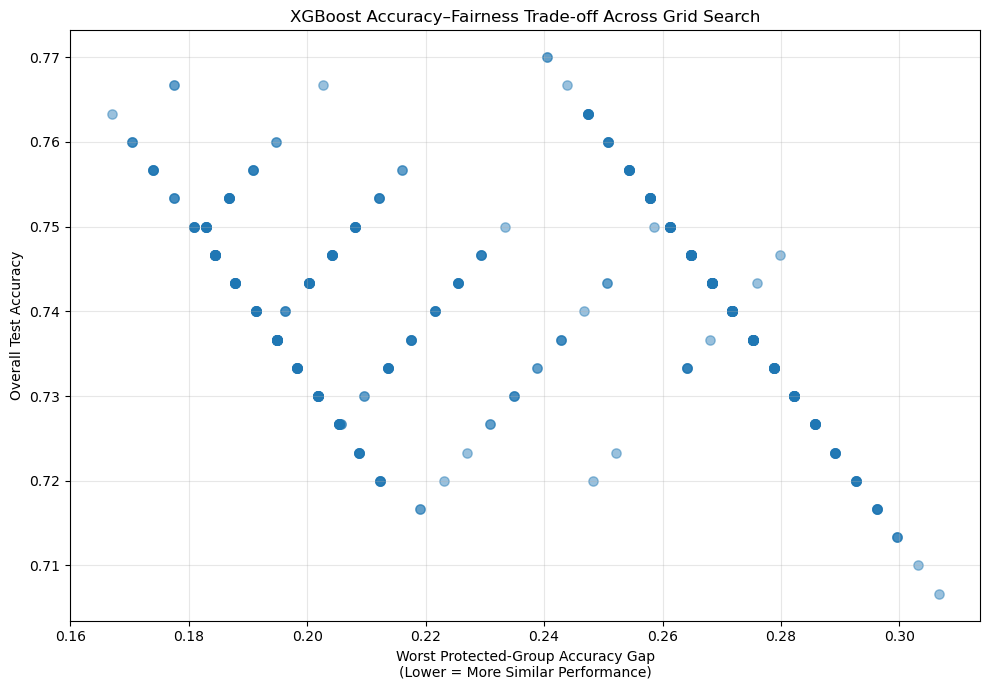

In [23]:
# ============================================================
# ACCURACY vs FAIRNESS TRADE-OFF
# ============================================================

plt.figure(figsize=(10, 7))

plt.scatter(
    grid_fairness_df['Worst Accuracy Gap'],
    grid_fairness_df['Accuracy'],
    alpha=0.45,
    s=45
)

plt.xlabel(
    'Worst Protected-Group Accuracy Gap\n'
    '(Lower = More Similar Performance)'
)

plt.ylabel('Overall Test Accuracy')

plt.title(
    'XGBoost Accuracy–Fairness Trade-off Across Grid Search'
)

plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

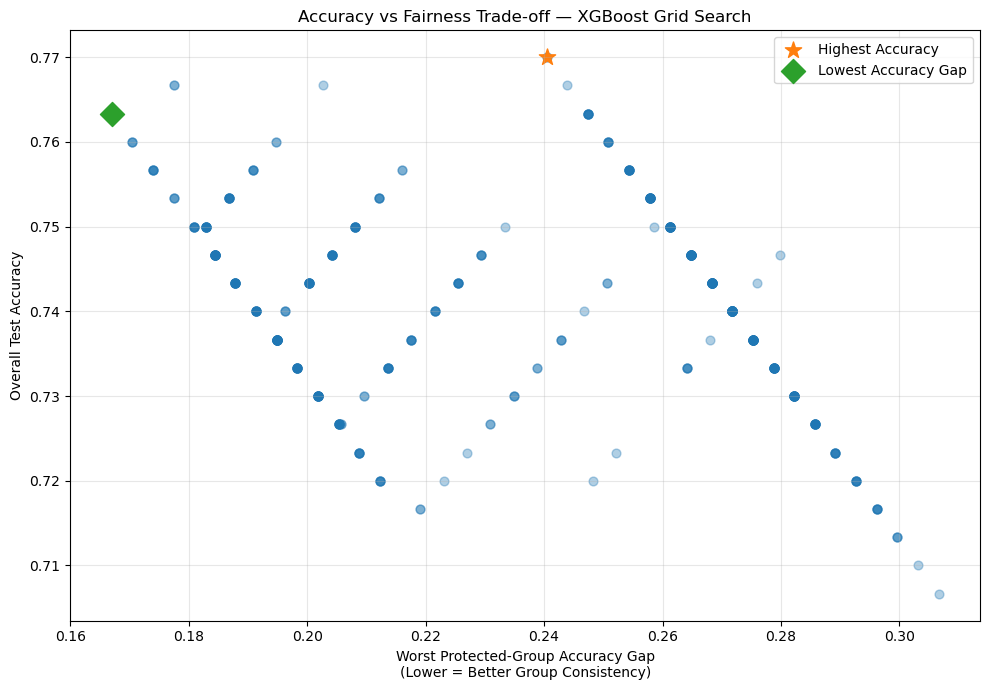

In [24]:
# ============================================================
# HIGHLIGHT EXTREME CONFIGURATIONS
# ============================================================

best_accuracy_idx = grid_fairness_df['Accuracy'].idxmax()

lowest_gap_idx = grid_fairness_df['Worst Accuracy Gap'].idxmin()

plt.figure(figsize=(10, 7))

plt.scatter(
    grid_fairness_df['Worst Accuracy Gap'],
    grid_fairness_df['Accuracy'],
    alpha=0.35,
    s=40
)

# Highest accuracy
plt.scatter(
    grid_fairness_df.loc[best_accuracy_idx, 'Worst Accuracy Gap'],
    grid_fairness_df.loc[best_accuracy_idx, 'Accuracy'],
    s=150,
    marker='*',
    label='Highest Accuracy'
)

# Lowest disparity
plt.scatter(
    grid_fairness_df.loc[lowest_gap_idx, 'Worst Accuracy Gap'],
    grid_fairness_df.loc[lowest_gap_idx, 'Accuracy'],
    s=150,
    marker='D',
    label='Lowest Accuracy Gap'
)

plt.xlabel(
    'Worst Protected-Group Accuracy Gap\n'
    '(Lower = Better Group Consistency)'
)

plt.ylabel('Overall Test Accuracy')

plt.title(
    'Accuracy vs Fairness Trade-off — XGBoost Grid Search'
)

plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

=== Model Performance Comparison ===
   Metric  Baseline XGBoost  Tuned XGBoost
 Accuracy          0.726667       0.740000
Precision          0.773504       0.748120
   Recall          0.861905       0.947619
 F1-Score          0.815315       0.836134
  ROC-AUC          0.739418       0.788942


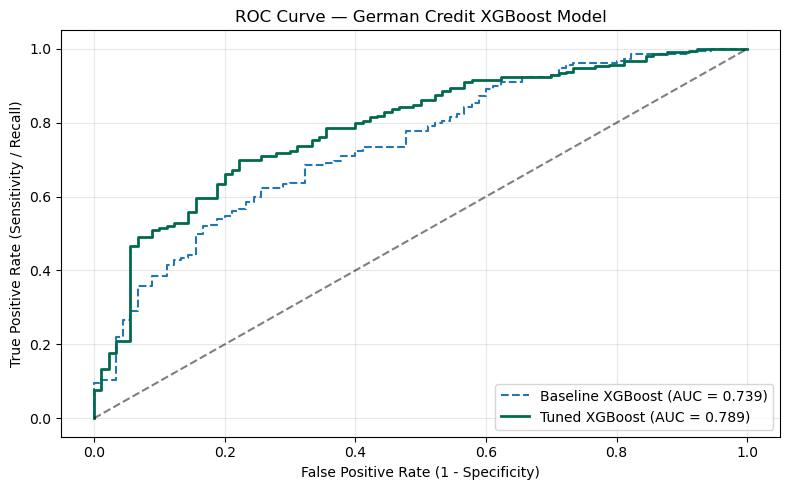

In [7]:
y_pred_tuned = best_xgb.predict(X_test_proc)
y_prob_tuned = best_xgb.predict_proba(X_test_proc)[:, 1]

metrics_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC'],
    'Baseline XGBoost': [
        accuracy_score(y_test, y_pred_base),
        precision_score(y_test, y_pred_base),
        recall_score(y_test, y_pred_base),
        f1_score(y_test, y_pred_base),
        roc_auc_score(y_test, y_prob_base)
    ],
    'Tuned XGBoost': [
        accuracy_score(y_test, y_pred_tuned),
        precision_score(y_test, y_pred_tuned),
        recall_score(y_test, y_pred_tuned),
        f1_score(y_test, y_pred_tuned),
        roc_auc_score(y_test, y_prob_tuned)
    ]
})

print("=== Model Performance Comparison ===")
print(metrics_df.to_string(index=False))

# Plot ROC Curves
fpr_base, tpr_base, _ = roc_curve(y_test, y_prob_base)
fpr_tuned, tpr_tuned, _ = roc_curve(y_test, y_prob_tuned)

plt.figure(figsize=(8, 5))
plt.plot(fpr_base, tpr_base, label=f"Baseline XGBoost (AUC = {roc_auc_score(y_test, y_prob_base):.3f})", linestyle='--')
plt.plot(fpr_tuned, tpr_tuned, label=f"Tuned XGBoost (AUC = {roc_auc_score(y_test, y_prob_tuned):.3f})", linewidth=2, color='#006a4e')
plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity / Recall)')
plt.title('ROC Curve — German Credit XGBoost Model')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


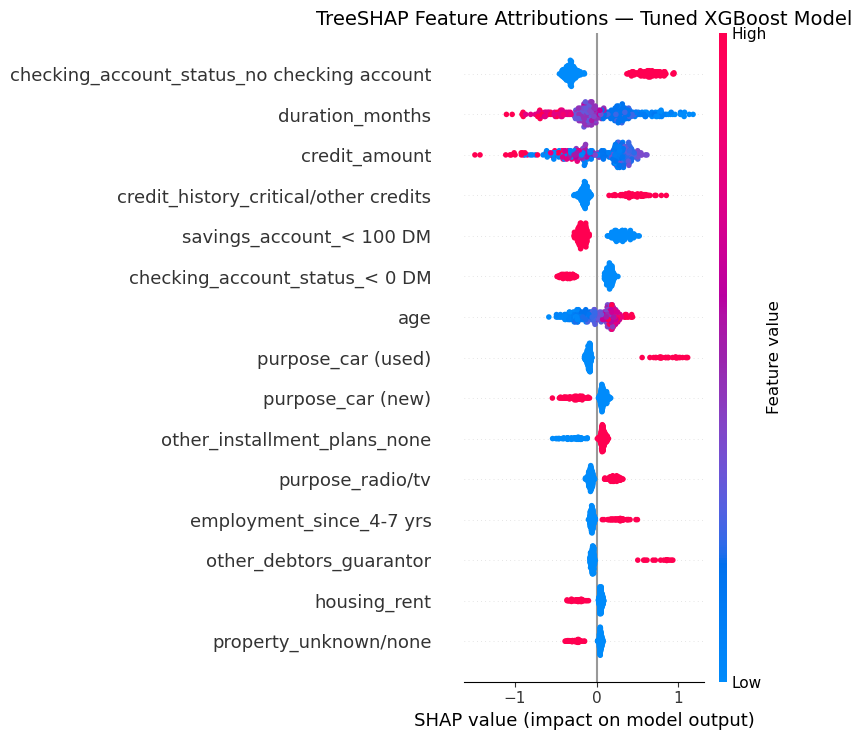

Top 15 Decision Features by SHAP Attribution:
                                    Feature  Mean_|SHAP|
checking_account_status_no checking account     0.454427
                            duration_months     0.345947
                              credit_amount     0.338353
      credit_history_critical/other credits     0.232329
                   savings_account_< 100 DM     0.232108
             checking_account_status_< 0 DM     0.208480
                                        age     0.190957
                         purpose_car (used)     0.178797
                          purpose_car (new)     0.129098
               other_installment_plans_none     0.117627
                           purpose_radio/tv     0.114959
                   employment_since_4-7 yrs     0.096591
                    other_debtors_guarantor     0.090152
                               housing_rent     0.087547
                      property_unknown/none     0.086075


In [8]:
# TreeSHAP Feature Importance Analysis
explainer = shap.TreeExplainer(best_xgb)
shap_values = explainer.shap_values(X_test_proc)

# Plot Summary Dot Plot
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test_proc, feature_names=all_feature_names, max_display=15, show=False)
plt.title("TreeSHAP Feature Attributions — Tuned XGBoost Model", fontsize=14)
plt.tight_layout()
plt.show()

# Mean Absolute SHAP Feature Importance Table
mean_shap = np.abs(shap_values).mean(axis=0)
top_shap_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Mean_|SHAP|': mean_shap
}).sort_values('Mean_|SHAP|', ascending=False).head(15)

print("Top 15 Decision Features by SHAP Attribution:")
print(top_shap_df.to_string(index=False))


=== XGBoost Subgroup Fairness Audit Summary ===
       Attribute                                  Subgroup  Sample N  Approval Rate  DIR (vs Ref)  SPD (vs Ref)  EOD (TPR Diff) Reference Group Audit Status
             sex                                      male       690         0.8797        1.0000        0.0000          0.0000            male         FAIR
             sex                                    female       310         0.8387        0.9534       -0.0410          0.0059            male         FAIR
       age_group                                       25+       851         0.8801        1.0000        0.0000          0.0000             25+         FAIR
       age_group                               young (<25)       149         0.7919        0.8998       -0.0882          0.0210             25+         FAIR
  foreign_worker                                       yes       963         0.8640        1.0000        0.0000          0.0000             yes         FAIR
  foreign_

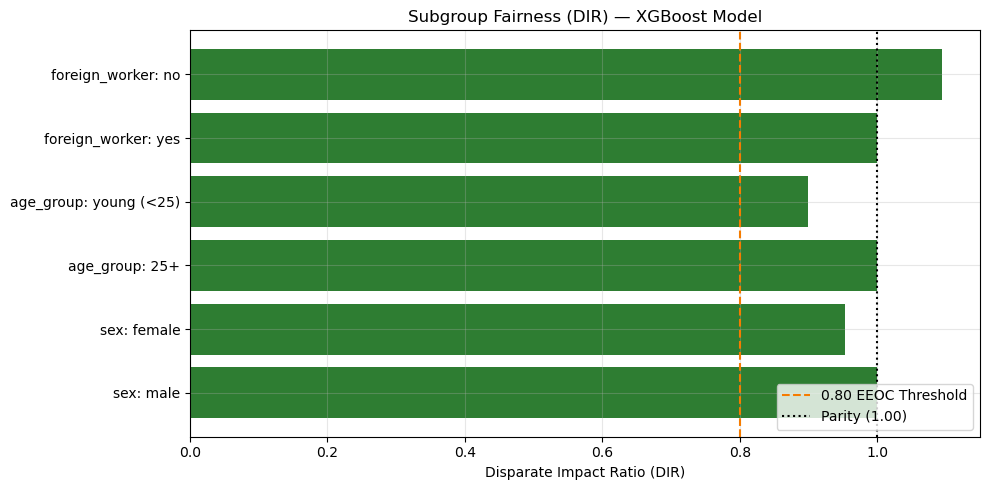

In [9]:
# Perform Subgroup Fairness Audit for Tuned XGBoost Model
# Evaluate predictions across full dataset
X_full_proc = preprocessor.transform(X[feature_cols])
df['xgb_pred'] = best_xgb.predict(X_full_proc)
df['xgb_prob'] = best_xgb.predict_proba(X_full_proc)[:, 1]

fairness_results = []

for attr in ['sex', 'age_group', 'foreign_worker', 'employment_since', 'housing', 'job']:
    ref_val = df[attr].value_counts().index[0]  # Reference group = largest group
    ref_sub = df[df[attr] == ref_val]
    ref_rate = ref_sub['xgb_pred'].mean()
    ref_tpr = (ref_sub[ref_sub['target'] == 1]['xgb_pred'] == 1).mean()

    for val in df[attr].unique():
        sub = df[df[attr] == val]
        n_sub = len(sub)
        sub_rate = sub['xgb_pred'].mean()
        sub_tpr = (sub[sub['target'] == 1]['xgb_pred'] == 1).mean() if (sub['target'] == 1).sum() > 0 else 0.0

        dir_val = sub_rate / ref_rate if ref_rate > 0 else 1.0
        spd_val = sub_rate - ref_rate
        eod_val = abs(sub_tpr - ref_tpr)

        severity = 'CONCERN' if dir_val < 0.70 or abs(spd_val) > 0.15 else ('REVIEW' if dir_val < 0.80 or abs(spd_val) > 0.10 else 'FAIR')

        fairness_results.append({
            'Attribute': attr,
            'Subgroup': str(val),
            'Sample N': n_sub,
            'Approval Rate': round(sub_rate, 4),
            'DIR (vs Ref)': round(dir_val, 4),
            'SPD (vs Ref)': round(spd_val, 4),
            'EOD (TPR Diff)': round(eod_val, 4),
            'Reference Group': str(ref_val),
            'Audit Status': severity
        })

fairness_df = pd.DataFrame(fairness_results)

print("=== XGBoost Subgroup Fairness Audit Summary ===")
print(fairness_df.to_string(index=False))

# Plot Disparate Impact Ratios across protected subgroups
plt.figure(figsize=(10, 5))
sub_df = fairness_df[fairness_df['Attribute'].isin(['sex', 'age_group', 'foreign_worker'])].copy()
colors = ['#2E7D32' if status == 'FAIR' else ('#F57C00' if status == 'REVIEW' else '#D32F2F') for status in sub_df['Audit Status']]

plt.barh(sub_df['Attribute'] + ': ' + sub_df['Subgroup'], sub_df['DIR (vs Ref)'], color=colors)
plt.axvline(x=0.80, color='#F57C00', linestyle='--', label='0.80 EEOC Threshold')
plt.axvline(x=1.00, color='black', linestyle=':', label='Parity (1.00)')
plt.xlabel('Disparate Impact Ratio (DIR)')
plt.title('Subgroup Fairness (DIR) — XGBoost Model')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Version - 2

In [10]:
# ============================================================
# CELL 9 — Prepare TEST-SET Fairness Audit Data
# ============================================================

# Get demographic/subgroup attributes corresponding ONLY to X_test
test_indices = X_test.index

audit_test = df.loc[test_indices, [
    'sex',
    'age_group',
    'foreign_worker',
    'employment_since',
    'housing',
    'job',
    'target'
]].copy()

# Add model predictions from the held-out test set
audit_test['y_pred'] = y_pred_tuned
audit_test['y_prob'] = y_prob_tuned

print("Fairness audit dataset:")
print(f"Samples: {len(audit_test)}")
print(f"Positive class rate: {audit_test['target'].mean():.3f}")

audit_test.head()

Fairness audit dataset:
Samples: 300
Positive class rate: 0.700


,sex,age_group,foreign_worker,employment_since,housing,job,target,y_pred,y_prob
80,female,25+,yes,< 1 yr,own,skilled,0,1,0.983191
157,male,25+,yes,>= 7 yrs,own,unskilled resident,1,1,0.507634
65,male,25+,yes,>= 7 yrs,own,skilled,1,1,0.956965
489,male,25+,yes,1-4 yrs,rent,skilled,1,1,0.936512
804,female,young (<25),yes,unemployed,rent,unemployed/unskilled non-res,1,1,0.667000


In [12]:
# ============================================================
# CELL 10 — Fairness Metric Functions
# ============================================================

def calculate_subgroup_metrics(
    data,
    attribute,
    reference_group=None,
    min_n=10
):
    """
    Calculate subgroup fairness metrics relative to a reference group.

    Metrics:
    - Selection Rate
    - Disparate Impact Ratio (DIR)
    - Statistical Parity Difference (SPD)
    - True Positive Rate (TPR)
    - Equal Opportunity Difference (EOD)
    """

    results = []

    # Automatically choose largest subgroup if reference isn't specified
    if reference_group is None:
        reference_group = data[attribute].value_counts().idxmax()

    ref = data[data[attribute] == reference_group]

    ref_selection_rate = ref['y_pred'].mean()

    ref_positive = ref[ref['target'] == 1]

    ref_tpr = (
        ref_positive['y_pred'].mean()
        if len(ref_positive) > 0
        else np.nan
    )

    for subgroup in sorted(data[attribute].dropna().unique()):

        sub = data[data[attribute] == subgroup]
        n = len(sub)

        # Ignore very small groups
        if n < min_n:
            continue

        selection_rate = sub['y_pred'].mean()

        positive = sub[sub['target'] == 1]

        tpr = (
            positive['y_pred'].mean()
            if len(positive) > 0
            else np.nan
        )

        # Disparate Impact Ratio
        dir_value = (
            selection_rate / ref_selection_rate
            if ref_selection_rate > 0
            else np.nan
        )

        # Statistical Parity Difference
        spd_value = selection_rate - ref_selection_rate

        # Equal Opportunity Difference
        eod_value = (
            tpr - ref_tpr
            if not np.isnan(tpr) and not np.isnan(ref_tpr)
            else np.nan
        )

        results.append({
            'Attribute': attribute,
            'Subgroup': str(subgroup),
            'Sample N': n,
            'Selection Rate': round(selection_rate, 4),
            'DIR': round(dir_value, 4),
            'SPD': round(spd_value, 4),
            'TPR': round(tpr, 4) if not np.isnan(tpr) else np.nan,
            'EOD': round(eod_value, 4) if not np.isnan(eod_value) else np.nan,
            'Reference Group': str(reference_group)
        })

    return pd.DataFrame(results)

In [13]:
# ============================================================
# CELL 11 — Protected Attribute Fairness Audit
# ============================================================

protected_attributes = [
    'sex',
    'age_group',
    'foreign_worker'
]

protected_results = []

for attr in protected_attributes:

    result = calculate_subgroup_metrics(
        audit_test,
        attribute=attr,
        min_n=10
    )

    protected_results.append(result)

protected_fairness_df = pd.concat(
    protected_results,
    ignore_index=True
)

print("=== PROTECTED ATTRIBUTE FAIRNESS AUDIT ===")
display(protected_fairness_df)

=== PROTECTED ATTRIBUTE FAIRNESS AUDIT ===


,Attribute,Subgroup,Sample N,Selection Rate,DIR,SPD,TPR,EOD,Reference Group
0,sex,female,96,0.8958,1.0153,0.0135,0.9365,-0.0159,male
1,sex,male,204,0.8824,1.0000,0.0000,0.9524,0.0000,male
2,age_group,25+,253,0.8933,1.0000,0.0000,0.9565,0.0000,25+
3,age_group,young (<25),47,0.8511,0.9527,-0.0422,0.8846,-0.0719,25+
4,foreign_worker,no,13,1.0000,1.1344,0.1185,1.0000,0.0556,yes
5,foreign_worker,yes,287,0.8815,1.0000,0.0000,0.9444,0.0000,yes


In [14]:
# ============================================================
# CELL 12 — Fairness Diagnostic / Audit Status
# ============================================================

def assign_audit_status(row):

    dir_value = row['DIR']
    spd_value = abs(row['SPD'])
    eod_value = abs(row['EOD']) if not pd.isna(row['EOD']) else 0

    # Strong concern
    if (
        dir_value < 0.70
        or spd_value > 0.15
        or eod_value > 0.15
    ):
        return 'CONCERN'

    # Requires investigation
    elif (
        dir_value < 0.80
        or spd_value > 0.10
        or eod_value > 0.10
    ):
        return 'REVIEW'

    # No metric-level flag
    else:
        return 'NO FLAG'


protected_fairness_df['Audit Status'] = (
    protected_fairness_df.apply(assign_audit_status, axis=1)
)

display(protected_fairness_df)

,Attribute,Subgroup,Sample N,Selection Rate,DIR,SPD,TPR,EOD,Reference Group,Audit Status
0,sex,female,96,0.8958,1.0153,0.0135,0.9365,-0.0159,male,NO FLAG
1,sex,male,204,0.8824,1.0000,0.0000,0.9524,0.0000,male,NO FLAG
2,age_group,25+,253,0.8933,1.0000,0.0000,0.9565,0.0000,25+,NO FLAG
3,age_group,young (<25),47,0.8511,0.9527,-0.0422,0.8846,-0.0719,25+,NO FLAG
4,foreign_worker,no,13,1.0000,1.1344,0.1185,1.0000,0.0556,yes,REVIEW
5,foreign_worker,yes,287,0.8815,1.0000,0.0000,0.9444,0.0000,yes,NO FLAG


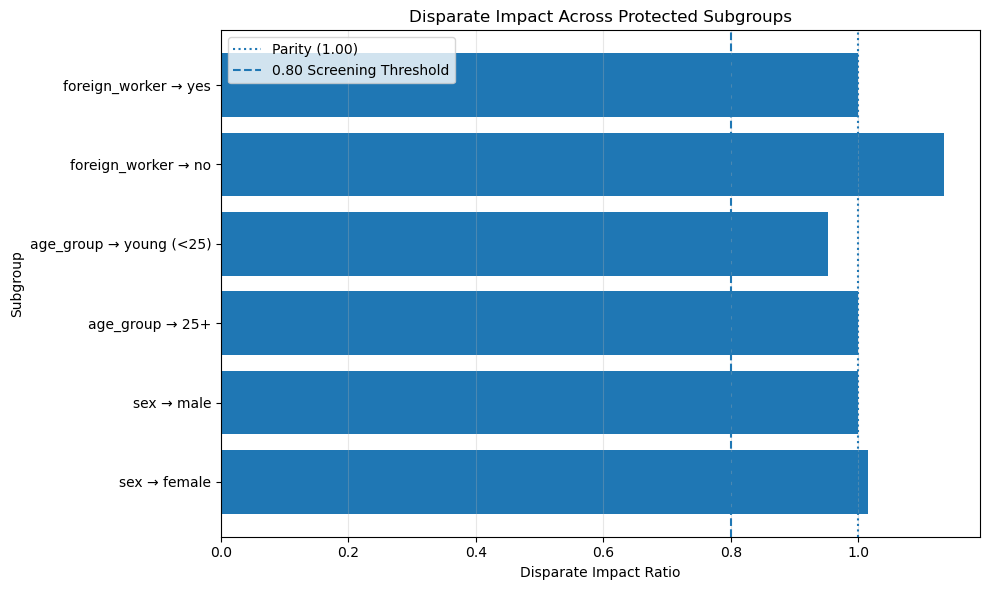

In [15]:
# ============================================================
# CELL 13 — Protected Attribute DIR Visualization
# ============================================================

plt.figure(figsize=(10, 6))

plot_df = protected_fairness_df.copy()

plt.barh(
    plot_df['Attribute'] + ' → ' + plot_df['Subgroup'],
    plot_df['DIR']
)

plt.axvline(
    1.0,
    linestyle=':',
    label='Parity (1.00)'
)

plt.axvline(
    0.80,
    linestyle='--',
    label='0.80 Screening Threshold'
)

plt.xlabel('Disparate Impact Ratio')
plt.ylabel('Subgroup')
plt.title('Disparate Impact Across Protected Subgroups')

plt.legend()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

In [16]:
# ============================================================
# CELL 14 — Contextual Subgroup Analysis
# ============================================================

contextual_attributes = [
    'employment_since',
    'housing',
    'job'
]

contextual_results = []

for attr in contextual_attributes:

    result = calculate_subgroup_metrics(
        audit_test,
        attribute=attr,
        min_n=10
    )

    contextual_results.append(result)

contextual_fairness_df = pd.concat(
    contextual_results,
    ignore_index=True
)

contextual_fairness_df['Audit Status'] = (
    contextual_fairness_df.apply(assign_audit_status, axis=1)
)

print("=== CONTEXTUAL SUBGROUP ANALYSIS ===")
display(contextual_fairness_df)

=== CONTEXTUAL SUBGROUP ANALYSIS ===


,Attribute,Subgroup,Sample N,Selection Rate,DIR,SPD,TPR,EOD,Reference Group,Audit Status
0,employment_since,1-4 yrs,105,0.8952,1.0000,0.0000,0.9577,0.0000,1-4 yrs,NO FLAG
1,employment_since,4-7 yrs,55,0.9091,1.0155,0.0139,0.9773,0.0195,1-4 yrs,NO FLAG
2,employment_since,< 1 yr,45,0.8444,0.9433,-0.0508,0.8333,-0.1244,1-4 yrs,REVIEW
3,employment_since,>= 7 yrs,72,0.9028,1.0084,0.0075,0.9818,0.0241,1-4 yrs,NO FLAG
4,employment_since,unemployed,23,0.8261,0.9228,-0.0692,0.8750,-0.0827,1-4 yrs,NO FLAG
5,housing,for free,34,0.6765,0.7288,-0.2518,0.8421,-0.1258,own,CONCERN
6,housing,own,209,0.9282,1.0000,0.0000,0.9679,0.0000,own,NO FLAG
7,housing,rent,57,0.8596,0.9261,-0.0686,0.9143,-0.0537,own,NO FLAG
8,job,management/self-employed/highly qualified,44,0.8409,0.9506,-0.0437,0.8889,-0.0635,skilled,NO FLAG
9,job,skilled,182,0.8846,1.0000,0.0000,0.9524,0.0000,skilled,NO FLAG


In [17]:
# ============================================================
# CELL 15 — Intersectional Subgroup Analysis
# ============================================================

from itertools import combinations

intersection_attributes = [
    'sex',
    'age_group',
    'foreign_worker',
    'employment_since',
    'housing',
    'job'
]

intersection_results = []

# Generate 2-way intersections
for attr1, attr2 in combinations(intersection_attributes, 2):

    temp = audit_test.copy()

    temp['Intersection'] = (
        temp[attr1].astype(str)
        + ' + '
        + temp[attr2].astype(str)
    )

    # Calculate subgroup statistics
    for subgroup in temp['Intersection'].unique():

        sub = temp[temp['Intersection'] == subgroup]

        n = len(sub)

        # Minimum sample size
        if n < 15:
            continue

        selection_rate = sub['y_pred'].mean()

        positive = sub[sub['target'] == 1]

        tpr = (
            positive['y_pred'].mean()
            if len(positive) > 0
            else np.nan
        )

        intersection_results.append({
            'Attributes': f'{attr1} × {attr2}',
            'Subgroup': subgroup,
            'Sample N': n,
            'Selection Rate': selection_rate,
            'TPR': tpr
        })

intersection_df = pd.DataFrame(intersection_results)

print("=== INTERSECTIONAL SUBGROUP ANALYSIS ===")
print(f"Number of intersectional subgroups: {len(intersection_df)}")

display(
    intersection_df.sort_values(
        'Selection Rate'
    ).head(20)
)

=== INTERSECTIONAL SUBGROUP ANALYSIS ===
Number of intersectional subgroups: 70


,Attributes,Subgroup,Sample N,Selection Rate,TPR
69,housing × job,for free + skilled,20,0.650000,0.833333
18,sex × housing,male + for free,26,0.653846,0.866667
48,foreign_worker × housing,yes + for free,34,0.676471,0.842105
36,age_group × housing,25+ + for free,32,0.718750,0.888889
56,employment_since × housing,unemployed + own,16,0.750000,0.800000
66,housing × job,rent + skilled,32,0.781250,0.812500
31,age_group × employment_since,25+ + unemployed,19,0.789474,0.833333
6,sex × employment_since,female + < 1 yr,24,0.791667,0.777778
23,sex × job,male + management/self-employed/highly qualified,30,0.800000,0.857143
44,foreign_worker × employment_since,yes + unemployed,23,0.826087,0.875000


In [18]:
# ============================================================
# CELL 16 — Intersectional Disparity Detection
# ============================================================

overall_selection_rate = audit_test['y_pred'].mean()

overall_positive = audit_test[audit_test['target'] == 1]

overall_tpr = overall_positive['y_pred'].mean()

intersection_df['DIR_vs_Overall'] = (
    intersection_df['Selection Rate']
    / overall_selection_rate
)

intersection_df['SPD_vs_Overall'] = (
    intersection_df['Selection Rate']
    - overall_selection_rate
)

intersection_df['EOD_vs_Overall'] = (
    intersection_df['TPR']
    - overall_tpr
)

intersection_df['Abs_SPD'] = (
    intersection_df['SPD_vs_Overall'].abs()
)

intersection_df['Abs_EOD'] = (
    intersection_df['EOD_vs_Overall'].abs()
)

display(
    intersection_df.sort_values(
        'Abs_SPD',
        ascending=False
    ).head(20)
)

,Attributes,Subgroup,Sample N,Selection Rate,TPR,DIR_vs_Overall,SPD_vs_Overall,EOD_vs_Overall,Abs_SPD,Abs_EOD
69,housing × job,for free + skilled,20,0.650000,0.833333,0.733083,-0.236667,-0.114286,0.236667,0.114286
18,sex × housing,male + for free,26,0.653846,0.866667,0.737420,-0.232821,-0.080952,0.232821,0.080952
48,foreign_worker × housing,yes + for free,34,0.676471,0.842105,0.762937,-0.210196,-0.105514,0.210196,0.105514
36,age_group × housing,25+ + for free,32,0.718750,0.888889,0.810620,-0.167917,-0.058730,0.167917,0.058730
56,employment_since × housing,unemployed + own,16,0.750000,0.800000,0.845865,-0.136667,-0.147619,0.136667,0.147619
59,employment_since × job,>= 7 yrs + unskilled resident,15,1.000000,1.000000,1.127820,0.113333,0.052381,0.113333,0.052381
66,housing × job,rent + skilled,32,0.781250,0.812500,0.881109,-0.105417,-0.135119,0.105417,0.135119
31,age_group × employment_since,25+ + unemployed,19,0.789474,0.833333,0.890384,-0.097193,-0.114286,0.097193,0.114286
6,sex × employment_since,female + < 1 yr,24,0.791667,0.777778,0.892857,-0.095000,-0.169841,0.095000,0.169841
55,employment_since × housing,4-7 yrs + own,43,0.976744,1.000000,1.101591,0.090078,0.052381,0.090078,0.052381


In [19]:
# ============================================================
# CELL 17 — Automatic Subgroup Discovery
# ============================================================

def subgroup_flag(row):

    if (
        row['DIR_vs_Overall'] < 0.80
        or row['DIR_vs_Overall'] > 1.25
        or row['Abs_SPD'] > 0.10
        or row['Abs_EOD'] > 0.10
    ):
        return 'FLAG'

    return 'NO FLAG'


intersection_df['Diagnostic'] = (
    intersection_df.apply(
        subgroup_flag,
        axis=1
    )
)

flagged_subgroups = (
    intersection_df[
        intersection_df['Diagnostic'] == 'FLAG'
    ]
    .sort_values(
        'Abs_SPD',
        ascending=False
    )
)

print("=== FLAGGED INTERSECTIONAL SUBGROUPS ===")

display(
    flagged_subgroups.head(20)
)

=== FLAGGED INTERSECTIONAL SUBGROUPS ===


,Attributes,Subgroup,Sample N,Selection Rate,TPR,DIR_vs_Overall,SPD_vs_Overall,EOD_vs_Overall,Abs_SPD,Abs_EOD,Diagnostic
69,housing × job,for free + skilled,20,0.650000,0.833333,0.733083,-0.236667,-0.114286,0.236667,0.114286,FLAG
18,sex × housing,male + for free,26,0.653846,0.866667,0.737420,-0.232821,-0.080952,0.232821,0.080952,FLAG
48,foreign_worker × housing,yes + for free,34,0.676471,0.842105,0.762937,-0.210196,-0.105514,0.210196,0.105514,FLAG
36,age_group × housing,25+ + for free,32,0.718750,0.888889,0.810620,-0.167917,-0.058730,0.167917,0.058730,FLAG
56,employment_since × housing,unemployed + own,16,0.750000,0.800000,0.845865,-0.136667,-0.147619,0.136667,0.147619,FLAG
59,employment_since × job,>= 7 yrs + unskilled resident,15,1.000000,1.000000,1.127820,0.113333,0.052381,0.113333,0.052381,FLAG
66,housing × job,rent + skilled,32,0.781250,0.812500,0.881109,-0.105417,-0.135119,0.105417,0.135119,FLAG
31,age_group × employment_since,25+ + unemployed,19,0.789474,0.833333,0.890384,-0.097193,-0.114286,0.097193,0.114286,FLAG
6,sex × employment_since,female + < 1 yr,24,0.791667,0.777778,0.892857,-0.095000,-0.169841,0.095000,0.169841,FLAG
41,foreign_worker × employment_since,yes + < 1 yr,44,0.840909,0.826087,0.948394,-0.045758,-0.121532,0.045758,0.121532,FLAG


In [20]:
# ============================================================
# CELL 18 — Subgroup Reliability
# ============================================================

intersection_df['Reliability'] = np.where(
    intersection_df['Sample N'] >= 50,
    'HIGH',
    np.where(
        intersection_df['Sample N'] >= 30,
        'MEDIUM',
        'LOW'
    )
)

flagged_subgroups = (
    intersection_df[
        (intersection_df['Diagnostic'] == 'FLAG') &
        (intersection_df['Reliability'].isin(['HIGH', 'MEDIUM']))
    ]
    .sort_values(
        ['Abs_SPD', 'Sample N'],
        ascending=[False, False]
    )
)

print("=== FLAGGED SUBGROUPS WITH ADEQUATE SAMPLE SIZE ===")

display(flagged_subgroups.head(20))

=== FLAGGED SUBGROUPS WITH ADEQUATE SAMPLE SIZE ===


,Attributes,Subgroup,Sample N,Selection Rate,TPR,DIR_vs_Overall,SPD_vs_Overall,EOD_vs_Overall,Abs_SPD,Abs_EOD,Diagnostic,Reliability
48,foreign_worker × housing,yes + for free,34,0.676471,0.842105,0.762937,-0.210196,-0.105514,0.210196,0.105514,FLAG,MEDIUM
36,age_group × housing,25+ + for free,32,0.718750,0.888889,0.810620,-0.167917,-0.058730,0.167917,0.058730,FLAG,MEDIUM
66,housing × job,rent + skilled,32,0.781250,0.812500,0.881109,-0.105417,-0.135119,0.105417,0.135119,FLAG,MEDIUM
41,foreign_worker × employment_since,yes + < 1 yr,44,0.840909,0.826087,0.948394,-0.045758,-0.121532,0.045758,0.121532,FLAG,MEDIUM
26,age_group × employment_since,25+ + < 1 yr,33,0.848485,0.842105,0.956938,-0.038182,-0.105514,0.038182,0.105514,FLAG,MEDIUM


In [21]:
# ============================================================
# CELL 19 — Automated Fairness Report
# ============================================================

print("=" * 70)
print("FAIRNESS AUDIT REPORT — TUNED XGBOOST")
print("=" * 70)

print("\nMODEL PERFORMANCE")
print("-" * 40)

print(f"Accuracy : {accuracy_score(y_test, y_pred_tuned):.4f}")
print(f"F1 Score : {f1_score(y_test, y_pred_tuned):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_prob_tuned):.4f}")

print("\nPROTECTED ATTRIBUTE AUDIT")
print("-" * 40)

display(
    protected_fairness_df[
        [
            'Attribute',
            'Subgroup',
            'Sample N',
            'Selection Rate',
            'DIR',
            'SPD',
            'EOD',
            'Audit Status'
        ]
    ]
)

print("\nINTERSECTIONAL FINDINGS")
print("-" * 40)

if len(flagged_subgroups) == 0:

    print("No intersectional subgroup passed the current flagging criteria.")

else:

    display(
        flagged_subgroups[
            [
                'Attributes',
                'Subgroup',
                'Sample N',
                'DIR_vs_Overall',
                'SPD_vs_Overall',
                'EOD_vs_Overall',
                'Reliability',
                'Diagnostic'
            ]
        ].head(15)
    )

print("\n" + "=" * 70)


FAIRNESS AUDIT REPORT — TUNED XGBOOST

MODEL PERFORMANCE
----------------------------------------
Accuracy : 0.7400
F1 Score : 0.8361
ROC-AUC  : 0.7889

PROTECTED ATTRIBUTE AUDIT
----------------------------------------


,Attribute,Subgroup,Sample N,Selection Rate,DIR,SPD,EOD,Audit Status
0,sex,female,96,0.8958,1.0153,0.0135,-0.0159,NO FLAG
1,sex,male,204,0.8824,1.0000,0.0000,0.0000,NO FLAG
2,age_group,25+,253,0.8933,1.0000,0.0000,0.0000,NO FLAG
3,age_group,young (<25),47,0.8511,0.9527,-0.0422,-0.0719,NO FLAG
4,foreign_worker,no,13,1.0000,1.1344,0.1185,0.0556,REVIEW
5,foreign_worker,yes,287,0.8815,1.0000,0.0000,0.0000,NO FLAG



INTERSECTIONAL FINDINGS
----------------------------------------


,Attributes,Subgroup,Sample N,DIR_vs_Overall,SPD_vs_Overall,EOD_vs_Overall,Reliability,Diagnostic
48,foreign_worker × housing,yes + for free,34,0.762937,-0.210196,-0.105514,MEDIUM,FLAG
36,age_group × housing,25+ + for free,32,0.810620,-0.167917,-0.058730,MEDIUM,FLAG
66,housing × job,rent + skilled,32,0.881109,-0.105417,-0.135119,MEDIUM,FLAG
41,foreign_worker × employment_since,yes + < 1 yr,44,0.948394,-0.045758,-0.121532,MEDIUM,FLAG
26,age_group × employment_since,25+ + < 1 yr,33,0.956938,-0.038182,-0.105514,MEDIUM,FLAG


In [25]:
# ============================================================
# CELL 20 — Inspect Records from Flagged Subgroups
# ============================================================

def get_flagged_records(
    flagged_df,
    audit_data,
    max_groups=10
):
    """
    Retrieve the actual test-set records belonging to
    flagged intersectional subgroups.
    """

    flagged_records = []

    for _, row in flagged_df.head(max_groups).iterrows():

        attributes = row['Attributes'].split(' × ')
        values = row['Subgroup'].split(' + ')

        # Start with all records
        mask = pd.Series(True, index=audit_data.index)

        # Match every attribute/value combination
        for attr, value in zip(attributes, values):
            mask &= (
                audit_data[attr].astype(str) == str(value)
            )

        subgroup_records = audit_data.loc[mask].copy()

        # Add information about why this subgroup was flagged
        subgroup_records['Flagged Attributes'] = row['Attributes']
        subgroup_records['Flagged Subgroup'] = row['Subgroup']
        subgroup_records['DIR'] = row['DIR_vs_Overall']
        subgroup_records['SPD'] = row['SPD_vs_Overall']
        subgroup_records['EOD'] = row['EOD_vs_Overall']
        subgroup_records['Reliability'] = row['Reliability']

        flagged_records.append(subgroup_records)

    if not flagged_records:
        return pd.DataFrame()

    return pd.concat(
        flagged_records,
        ignore_index=False
    )


flagged_records_df = get_flagged_records(
    flagged_subgroups,
    audit_test
)

print("=== RECORDS BELONGING TO FLAGGED SUBGROUPS ===")
print(f"Total flagged records: {len(flagged_records_df)}")

display(flagged_records_df)

=== RECORDS BELONGING TO FLAGGED SUBGROUPS ===
Total flagged records: 175


,sex,age_group,foreign_worker,employment_since,housing,job,target,y_pred,y_prob,Flagged Attributes,Flagged Subgroup,DIR,SPD,EOD,Reliability
87,male,25+,yes,1-4 yrs,for free,skilled,0,0,0.467653,foreign_worker × housing,yes + for free,0.762937,-0.210196,-0.105514,MEDIUM
310,male,25+,yes,unemployed,for free,unemployed/unskilled non-res,1,1,0.702991,foreign_worker × housing,yes + for free,0.762937,-0.210196,-0.105514,MEDIUM
374,female,25+,yes,>= 7 yrs,for free,management/self-employed/highly qualified,0,0,0.346403,foreign_worker × housing,yes + for free,0.762937,-0.210196,-0.105514,MEDIUM
511,male,25+,yes,1-4 yrs,for free,management/self-employed/highly qualified,1,1,0.957433,foreign_worker × housing,yes + for free,0.762937,-0.210196,-0.105514,MEDIUM
198,male,25+,yes,>= 7 yrs,for free,skilled,1,1,0.914269,foreign_worker × housing,yes + for free,0.762937,-0.210196,-0.105514,MEDIUM
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
514,male,25+,yes,< 1 yr,own,skilled,1,1,0.948680,age_group × employment_since,25+ + < 1 yr,0.956938,-0.038182,-0.105514,MEDIUM
475,female,25+,yes,< 1 yr,rent,skilled,0,0,0.476862,age_group × employment_since,25+ + < 1 yr,0.956938,-0.038182,-0.105514,MEDIUM
809,female,25+,yes,< 1 yr,rent,unemployed/unskilled non-res,0,1,0.751657,age_group × employment_since,25+ + < 1 yr,0.956938,-0.038182,-0.105514,MEDIUM
180,male,25+,yes,< 1 yr,own,skilled,0,1,0.758354,age_group × employment_since,25+ + < 1 yr,0.956938,-0.038182,-0.105514,MEDIUM


## Bias Mitigation and Testing

In [27]:
# ============================================================
# CELL 26 — Fairlearn Imports
# ============================================================

from fairlearn.reductions import (
    ExponentiatedGradient,
    DemographicParity,
    EqualizedOdds
)

from fairlearn.metrics import (
    demographic_parity_difference,
    demographic_parity_ratio,
    equalized_odds_difference,
    equalized_odds_ratio
)

from xgboost import XGBClassifier


In [28]:
# ============================================================
# CELL 27 — Prepare Data for Bias Mitigation
# ============================================================

X_train_mit = X_train_proc
X_test_mit = X_test_proc

# Protected attributes
sens_train = df.loc[X_train.index, [
    'sex',
    'age_group',
    'foreign_worker'
]].copy()

sens_test = df.loc[X_test.index, [
    'sex',
    'age_group',
    'foreign_worker'
]].copy()

print("Training samples:", len(X_train_mit))
print("Test samples:", len(X_test_mit))

display(sens_train.head())

Training samples: 700
Test samples: 300


,sex,age_group,foreign_worker
328,male,25+,yes
891,male,25+,yes
255,male,25+,yes
243,female,25+,yes
492,female,25+,yes


In [29]:
# ============================================================
# CELL 28 — Intersectional Protected Attributes
# ============================================================

# Pairwise intersections
sens_train['sex_age'] = (
    sens_train['sex'].astype(str)
    + ' × '
    + sens_train['age_group'].astype(str)
)

sens_test['sex_age'] = (
    sens_test['sex'].astype(str)
    + ' × '
    + sens_test['age_group'].astype(str)
)

sens_train['sex_foreign'] = (
    sens_train['sex'].astype(str)
    + ' × '
    + sens_train['foreign_worker'].astype(str)
)

sens_test['sex_foreign'] = (
    sens_test['sex'].astype(str)
    + ' × '
    + sens_test['foreign_worker'].astype(str)
)

sens_train['age_foreign'] = (
    sens_train['age_group'].astype(str)
    + ' × '
    + sens_train['foreign_worker'].astype(str)
)

sens_test['age_foreign'] = (
    sens_test['age_group'].astype(str)
    + ' × '
    + sens_test['foreign_worker'].astype(str)
)

# Full 3-way intersection
sens_train['sex_age_foreign'] = (
    sens_train['sex'].astype(str)
    + ' × '
    + sens_train['age_group'].astype(str)
    + ' × '
    + sens_train['foreign_worker'].astype(str)
)

sens_test['sex_age_foreign'] = (
    sens_test['sex'].astype(str)
    + ' × '
    + sens_test['age_group'].astype(str)
    + ' × '
    + sens_test['foreign_worker'].astype(str)
)

print("Intersectional sensitive attributes created.")

Intersectional sensitive attributes created.


In [30]:
# ============================================================
# CELL 29 — Bias Mitigation Models
# ============================================================

base_estimator = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42
)

mitigation_targets = {
    'sex': sens_train['sex'],
    'age_group': sens_train['age_group'],
    'foreign_worker': sens_train['foreign_worker'],
    'sex_age': sens_train['sex_age'],
    'sex_foreign': sens_train['sex_foreign'],
    'age_foreign': sens_train['age_foreign'],
    'sex_age_foreign': sens_train['sex_age_foreign']
}

mitigators = {}
mitigated_predictions = {}

for name, sensitive_feature in mitigation_targets.items():

    print(f"Training mitigation model: {name}")

    mitigator = ExponentiatedGradient(
        estimator=base_estimator,
        constraints=DemographicParity(),
        eps=0.01
    )

    mitigator.fit(
        X_train_mit,
        y_train,
        sensitive_features=sensitive_feature
    )

    mitigators[name] = mitigator

    mitigated_predictions[name] = (
        mitigator.predict(X_test_mit)
    )

    print(f"✓ {name} completed")

print("\nAll mitigation models trained.")

Training mitigation model: sex
✓ sex completed
Training mitigation model: age_group
✓ age_group completed
Training mitigation model: foreign_worker
✓ foreign_worker completed
Training mitigation model: sex_age
✓ sex_age completed
Training mitigation model: sex_foreign
✓ sex_foreign completed
Training mitigation model: age_foreign
✓ age_foreign completed
Training mitigation model: sex_age_foreign
✓ sex_age_foreign completed

All mitigation models trained.


In [31]:
# ============================================================
# CELL 30 — Before vs After Fairness
# ============================================================

baseline_pred = y_pred_tuned

comparison_results = []

for attr_name in mitigation_targets.keys():

    sensitive_test = sens_test[attr_name]

    # Baseline
    baseline_dp = demographic_parity_difference(
        y_test,
        baseline_pred,
        sensitive_features=sensitive_test
    )

    baseline_dir = demographic_parity_ratio(
        y_test,
        baseline_pred,
        sensitive_features=sensitive_test
    )

    baseline_eo = equalized_odds_difference(
        y_test,
        baseline_pred,
        sensitive_features=sensitive_test
    )

    # Mitigated
    mitigated_pred = mitigated_predictions[attr_name]

    mitigated_dp = demographic_parity_difference(
        y_test,
        mitigated_pred,
        sensitive_features=sensitive_test
    )

    mitigated_dir = demographic_parity_ratio(
        y_test,
        mitigated_pred,
        sensitive_features=sensitive_test
    )

    mitigated_eo = equalized_odds_difference(
        y_test,
        mitigated_pred,
        sensitive_features=sensitive_test
    )

    # Performance
    baseline_acc = accuracy_score(
        y_test,
        baseline_pred
    )

    mitigated_acc = accuracy_score(
        y_test,
        mitigated_pred
    )

    comparison_results.append({
        'Protected Attribute': attr_name,

        'Baseline Accuracy': baseline_acc,
        'Mitigated Accuracy': mitigated_acc,
        'Accuracy Change': mitigated_acc - baseline_acc,

        'Baseline DIR': baseline_dir,
        'Mitigated DIR': mitigated_dir,

        'Baseline SPD': baseline_dp,
        'Mitigated SPD': mitigated_dp,

        'Baseline EOD': baseline_eo,
        'Mitigated EOD': mitigated_eo
    })

mitigation_comparison_df = pd.DataFrame(
    comparison_results
)

display(
    mitigation_comparison_df.round(4)
)

,Protected Attribute,Baseline Accuracy,Mitigated Accuracy,Accuracy Change,Baseline DIR,Mitigated DIR,Baseline SPD,Mitigated SPD,Baseline EOD,Mitigated EOD
0,sex,0.74,0.7400,0.0000,0.9850,0.9840,0.0135,0.0129,0.1164,0.0340
1,age_group,0.74,0.7433,0.0033,0.9527,0.9527,0.0422,0.0393,0.0849,0.2878
2,foreign_worker,0.74,0.7267,-0.0133,0.8815,0.8380,0.1185,0.1496,0.2584,0.5955
3,sex_age,0.74,0.7367,-0.0033,0.9016,0.9164,0.0909,0.0722,0.2015,0.3444
4,sex_foreign,0.74,0.7367,-0.0033,0.8750,0.7812,0.1250,0.2188,1.0000,0.6061
5,age_foreign,0.74,0.7433,0.0033,0.8511,0.8486,0.1489,0.1397,0.2794,0.7143
6,sex_age_foreign,0.74,0.7267,-0.0133,0.8333,0.7657,0.1667,0.2343,1.0000,1.0000


In [32]:
# ============================================================
# CELL 31 — Fairness Improvement
# ============================================================

result = mitigation_comparison_df.copy()

result['DIR Improvement'] = (
    (result['Mitigated DIR'] - result['Baseline DIR']).abs()
)

result['SPD Reduction'] = (
    result['Baseline SPD'].abs()
    - result['Mitigated SPD'].abs()
)

result['EOD Reduction'] = (
    result['Baseline EOD'].abs()
    - result['Mitigated EOD'].abs()
)

result['Accuracy Change (%)'] = (
    result['Accuracy Change'] * 100
)

print("=== MITIGATION IMPACT ===")

display(
    result.round(4)
)

=== MITIGATION IMPACT ===


,Protected Attribute,Baseline Accuracy,Mitigated Accuracy,Accuracy Change,Baseline DIR,Mitigated DIR,Baseline SPD,Mitigated SPD,Baseline EOD,Mitigated EOD,DIR Improvement,SPD Reduction,EOD Reduction,Accuracy Change (%)
0,sex,0.74,0.7400,0.0000,0.9850,0.9840,0.0135,0.0129,0.1164,0.0340,0.0010,0.0006,0.0824,0.0000
1,age_group,0.74,0.7433,0.0033,0.9527,0.9527,0.0422,0.0393,0.0849,0.2878,0.0001,0.0029,-0.2029,0.3333
2,foreign_worker,0.74,0.7267,-0.0133,0.8815,0.8380,0.1185,0.1496,0.2584,0.5955,0.0436,-0.0311,-0.3371,-1.3333
3,sex_age,0.74,0.7367,-0.0033,0.9016,0.9164,0.0909,0.0722,0.2015,0.3444,0.0148,0.0187,-0.1429,-0.3333
4,sex_foreign,0.74,0.7367,-0.0033,0.8750,0.7812,0.1250,0.2188,1.0000,0.6061,0.0938,-0.0938,0.3939,-0.3333
5,age_foreign,0.74,0.7433,0.0033,0.8511,0.8486,0.1489,0.1397,0.2794,0.7143,0.0025,0.0092,-0.4349,0.3333
6,sex_age_foreign,0.74,0.7267,-0.0133,0.8333,0.7657,0.1667,0.2343,1.0000,1.0000,0.0676,-0.0676,0.0000,-1.3333


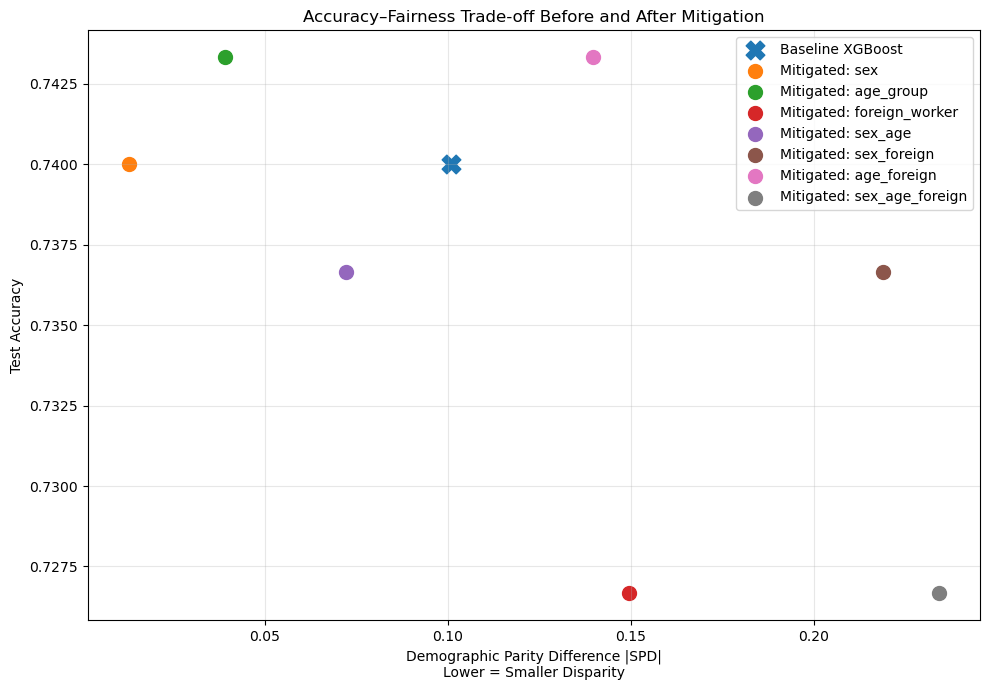

In [33]:
# ============================================================
# CELL 32 — Accuracy vs Fairness After Mitigation
# ============================================================

plt.figure(figsize=(10, 7))

# Baseline
baseline_dp_values = []

for attr in mitigation_targets.keys():

    dp = demographic_parity_difference(
        y_test,
        baseline_pred,
        sensitive_features=sens_test[attr]
    )

    baseline_dp_values.append(abs(dp))

baseline_fairness = np.mean(baseline_dp_values)

baseline_accuracy = accuracy_score(
    y_test,
    baseline_pred
)

plt.scatter(
    baseline_fairness,
    baseline_accuracy,
    s=180,
    marker='X',
    label='Baseline XGBoost'
)

# Mitigated models
for attr_name in mitigation_targets.keys():

    pred = mitigated_predictions[attr_name]

    dp = demographic_parity_difference(
        y_test,
        pred,
        sensitive_features=sens_test[attr_name]
    )

    accuracy = accuracy_score(
        y_test,
        pred
    )

    plt.scatter(
        abs(dp),
        accuracy,
        s=100,
        label=f'Mitigated: {attr_name}'
    )

plt.xlabel(
    'Demographic Parity Difference |SPD|'
    '\nLower = Smaller Disparity'
)

plt.ylabel('Test Accuracy')

plt.title(
    'Accuracy–Fairness Trade-off Before and After Mitigation'
)

plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [34]:
# ============================================================
# CELL 33 — Re-run Intersectional Audit After Mitigation
# ============================================================

def build_intersectional_audit(
    predictions,
    sensitive_data,
    y_true,
    min_n=15
):

    audit = sensitive_data.copy()

    audit['y_true'] = np.asarray(y_true)
    audit['y_pred'] = np.asarray(predictions)

    results = []

    intersection_attributes = [
        'sex',
        'age_group',
        'foreign_worker'
    ]

    from itertools import combinations

    for attr1, attr2 in combinations(
        intersection_attributes,
        2
    ):

        temp = audit.copy()

        temp['intersection'] = (
            temp[attr1].astype(str)
            + ' + '
            + temp[attr2].astype(str)
        )

        overall_rate = temp['y_pred'].mean()

        overall_positive = temp[
            temp['y_true'] == 1
        ]

        overall_tpr = (
            overall_positive['y_pred'].mean()
            if len(overall_positive) > 0
            else np.nan
        )

        for subgroup in temp['intersection'].unique():

            sub = temp[
                temp['intersection'] == subgroup
            ]

            if len(sub) < min_n:
                continue

            selection_rate = sub['y_pred'].mean()

            positive = sub[
                sub['y_true'] == 1
            ]

            tpr = (
                positive['y_pred'].mean()
                if len(positive) > 0
                else np.nan
            )

            results.append({
                'Attributes': f'{attr1} × {attr2}',
                'Subgroup': subgroup,
                'Sample N': len(sub),
                'Selection Rate': selection_rate,
                'DIR': (
                    selection_rate / overall_rate
                    if overall_rate > 0
                    else np.nan
                ),
                'SPD': (
                    selection_rate - overall_rate
                ),
                'EOD': (
                    tpr - overall_tpr
                    if not np.isnan(tpr)
                    else np.nan
                )
            })

    return pd.DataFrame(results)

In [35]:
# ============================================================
# CELL 34 — Compare Baseline and Mitigated Subgroups
# ============================================================

baseline_intersection = build_intersectional_audit(
    baseline_pred,
    sens_test,
    y_test
)

# Use the FULL intersection mitigator
mitigated_intersection = build_intersectional_audit(
    mitigated_predictions['sex_age_foreign'],
    sens_test,
    y_test
)

print("BASELINE INTERSECTIONAL FINDINGS")
display(
    baseline_intersection.sort_values(
        'DIR'
    ).head(10).round(4)
)

print("\nMITIGATED INTERSECTIONAL FINDINGS")
display(
    mitigated_intersection.sort_values(
        'DIR'
    ).head(10).round(4)
)

BASELINE INTERSECTIONAL FINDINGS


,Attributes,Subgroup,Sample N,Selection Rate,DIR,SPD,EOD
2,sex × age_group,female + young (<25),30,0.8333,0.9398,-0.0533,-0.0653
7,age_group × foreign_worker,young (<25) + yes,47,0.8511,0.9598,-0.0356,-0.0630
5,sex × foreign_worker,male + yes,192,0.8750,0.9868,-0.0117,0.0009
1,sex × age_group,male + 25+,187,0.8824,0.9951,-0.0043,0.0089
3,sex × age_group,male + young (<25),17,0.8824,0.9951,-0.0043,-0.0587
6,age_group × foreign_worker,25+ + yes,240,0.8875,1.0009,0.0008,0.0059
4,sex × foreign_worker,female + yes,95,0.8947,1.0091,0.0081,-0.0121
0,sex × age_group,female + 25+,66,0.9242,1.0424,0.0376,0.0089



MITIGATED INTERSECTIONAL FINDINGS


,Attributes,Subgroup,Sample N,Selection Rate,DIR,SPD,EOD
1,sex × age_group,male + 25+,187,0.7701,0.9707,-0.0233,-0.0164
5,sex × foreign_worker,male + yes,192,0.7708,0.9716,-0.0225,-0.0185
6,age_group × foreign_worker,25+ + yes,240,0.7833,0.9874,-0.0100,0.0065
3,sex × age_group,male + young (<25),17,0.8235,1.0381,0.0302,-0.0937
7,age_group × foreign_worker,young (<25) + yes,47,0.8298,1.0460,0.0365,-0.0253
4,sex × foreign_worker,female + yes,95,0.8316,1.0482,0.0382,0.0479
2,sex × age_group,female + young (<25),30,0.8333,1.0504,0.0400,0.0109
0,sex × age_group,female + 25+,66,0.8333,1.0504,0.0400,0.0634
